# Figure 5: 8-Trait Multi-Disease ComparisonCompare gsMap spatial enrichment across AD, PD, ALS, MS, FTD, T2D, SCZ, and Height.- Panel A: 8-trait x 8-organ heatmap- Panel B: T2D validation (Pancreas #1)- Panel C: AD vs PD brain cell types- Panel D: Myeloid enrichment gradient across neurodegen diseases- Panel E: Colon epithelial across 5 neurodegen diseases- Panel F: AD vs MS myeloid and colon comparison- Panel G: Height/SCZ as negative controls

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import glob
import os
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'sans-serif'
})

BASE = '../analysis/26_gsmap'
TRAITS = ['AD', 'MS', 'ALS', 'PD', 'FTD', 'T2D', 'SCZ', 'Height']
NEURODEGEN = ['AD', 'MS', 'ALS', 'PD', 'FTD']
COMMON_ORGANS = ['Brain', 'Bone_Marrow', 'Spleen', 'Lung', 'Liver', 'Colon', 'Ileum', 'Stomach']
myeloid_kw = ['myeloid', 'macrophage', 'microgl', 'monocyte', 'kupffer', 'dendri']

def fix_organ(name):
    """Extract organ from PanSci sample names like Brain_03_months, Brain_12m, Brain_18."""
    return re.sub(r'_\d+m$|_\d+_months$|_\d{2}$', '', str(name))

def is_myeloid(annot):
    """Check if annotation matches myeloid keywords."""
    a = str(annot).lower()
    return any(kw in a for kw in myeloid_kw)

# --- Load all cauchy files for all 8 traits ---
rows = []
for model_dir in ['models/gsmap_age_output', 'models/gsmap_output']:
    pattern = os.path.join(BASE, model_dir, '*/cauchy_combination/*.Cauchy.csv.gz')
    files = glob.glob(pattern)
    for f in files:
        fname = os.path.basename(f)
        # Extract trait from filename: {sample}_{trait}.Cauchy.csv.gz
        for t in TRAITS:
            if fname.endswith(f'_{t}.Cauchy.csv.gz'):
                sample = fname.replace(f'_{t}.Cauchy.csv.gz', '')
                organ = fix_organ(sample)
                # Also strip _CTRL1/_CTRL2 for 6w samples
                organ = re.sub(r'_CTRL\d+$', '', organ)
                try:
                    df = pd.read_csv(f)
                    df['trait'] = t
                    df['sample'] = sample
                    df['organ'] = organ
                    df['is_myeloid'] = df['annotation'].apply(is_myeloid)
                    rows.append(df)
                except Exception:
                    pass
                break

all_data = pd.concat(rows, ignore_index=True)
all_data['logp'] = -np.log10(all_data['p_cauchy'].clip(lower=1e-300))
print(f"Loaded {len(all_data)} rows, {all_data['trait'].nunique()} traits, {all_data['organ'].nunique()} organs")
print(f"Traits: {sorted(all_data['trait'].unique())}")
print(f"Organs: {sorted(all_data['organ'].unique())}")

# --- Pre-aggregated organ-level best p ---
organ_best = pd.read_csv(os.path.join(BASE, 'results/all_8traits_organ_best.csv'))
organ_best['logp'] = -np.log10(organ_best['p_cauchy'].clip(lower=1e-300))
print(f"\nOrgan-best: {len(organ_best)} rows")

Loaded 9569 rows, 8 traits, 18 organs
Traits: ['AD', 'ALS', 'FTD', 'Height', 'MS', 'PD', 'SCZ', 'T2D']
Organs: ['BAT', 'Bone_Marrow', 'Brain', 'Brown_Fat', 'Colon', 'Heart', 'Ileum', 'Kidney', 'Liver', 'Lung', 'Lymph_Node', 'Muscle', 'Pancreas', 'Skin', 'Small_Intestine', 'Spleen', 'Stomach', 'Thymus']

Organ-best: 112 rows


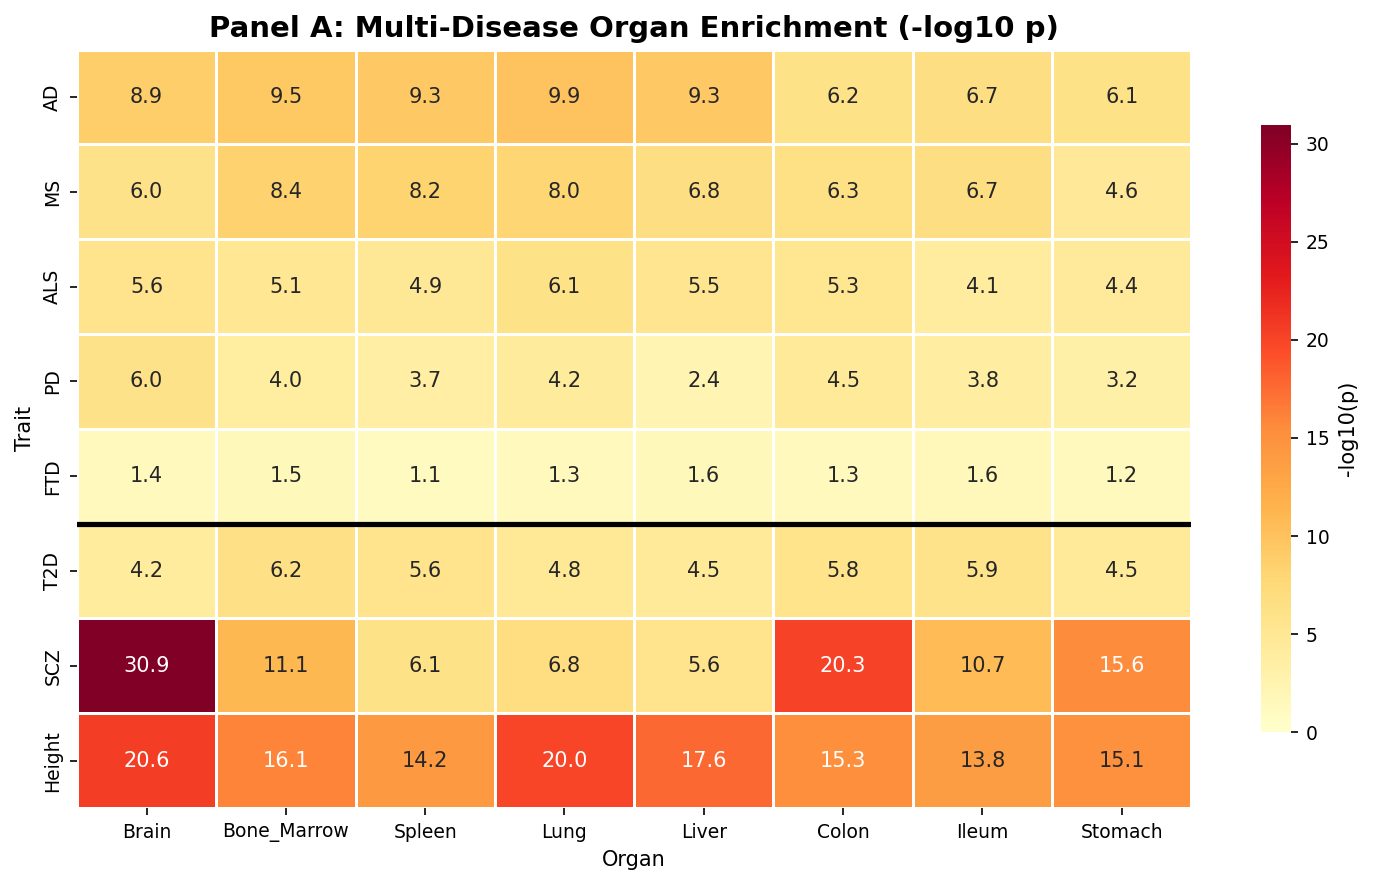

In [2]:
# Panel A: 8-trait x 8-organ heatmap

# Pivot organ_best to matrix
heat_df = organ_best[organ_best['organ'].isin(COMMON_ORGANS)].pivot_table(
    index='organ', columns='trait', values='logp', aggfunc='max'
)
heat_df = heat_df.reindex(index=COMMON_ORGANS, columns=TRAITS).fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))

# Create heatmap
sns.heatmap(
    heat_df.T, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label': '-log10(p)', 'shrink': 0.8},
    vmin=0
)

# Vertical separator between neurodegen (5) and controls (3)
ax.axhline(y=5, color='black', linewidth=2.5)

ax.set_title('Panel A: Multi-Disease Organ Enrichment (-log10 p)', fontsize=14, fontweight='bold')
ax.set_xlabel('Organ')
ax.set_ylabel('Trait')
plt.tight_layout()
plt.show()

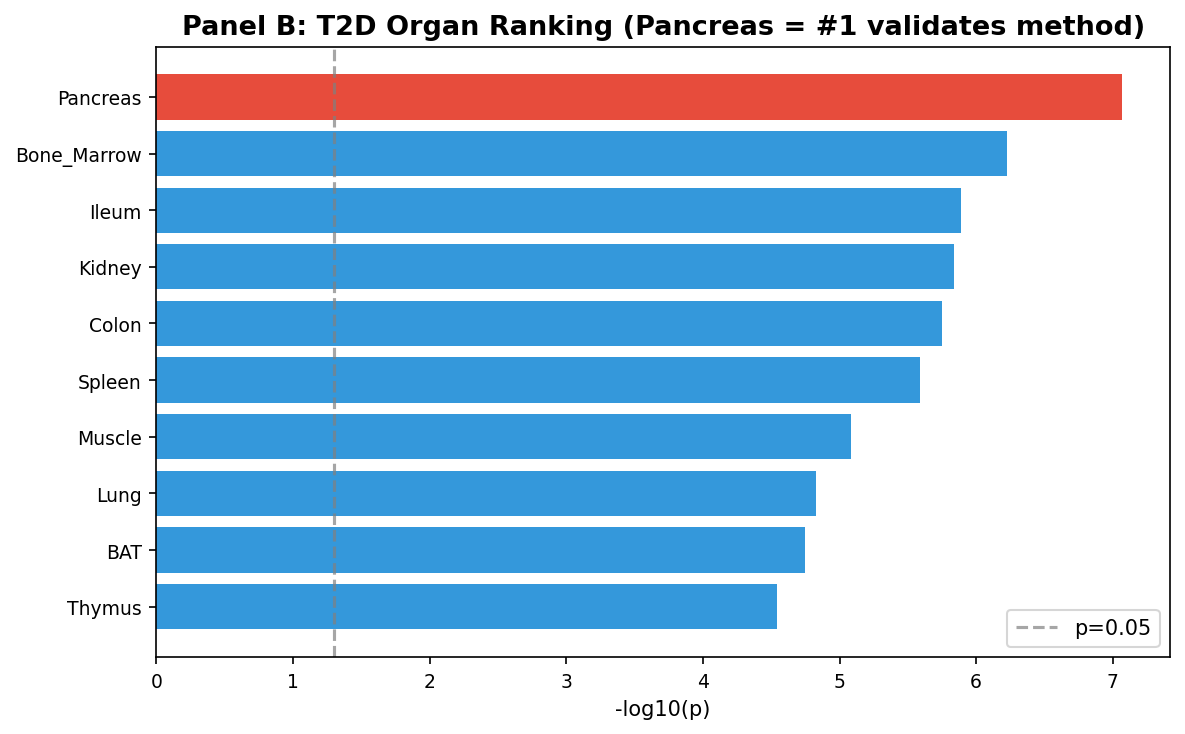

In [3]:
# Panel B: T2D validation - top organ = Pancreas

t2d = organ_best[organ_best['trait'] == 'T2D'].sort_values('logp', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if o == 'Pancreas' else '#3498db' for o in t2d['organ']]
ax.barh(range(len(t2d)), t2d['logp'].values, color=colors)
ax.set_yticks(range(len(t2d)))
ax.set_yticklabels(t2d['organ'].values)
ax.invert_yaxis()
ax.set_xlabel('-log10(p)')
ax.set_title('Panel B: T2D Organ Ranking (Pancreas = #1 validates method)', fontsize=13, fontweight='bold')
ax.axvline(x=-np.log10(0.05), color='grey', linestyle='--', alpha=0.7, label='p=0.05')
ax.legend()
plt.tight_layout()
plt.show()

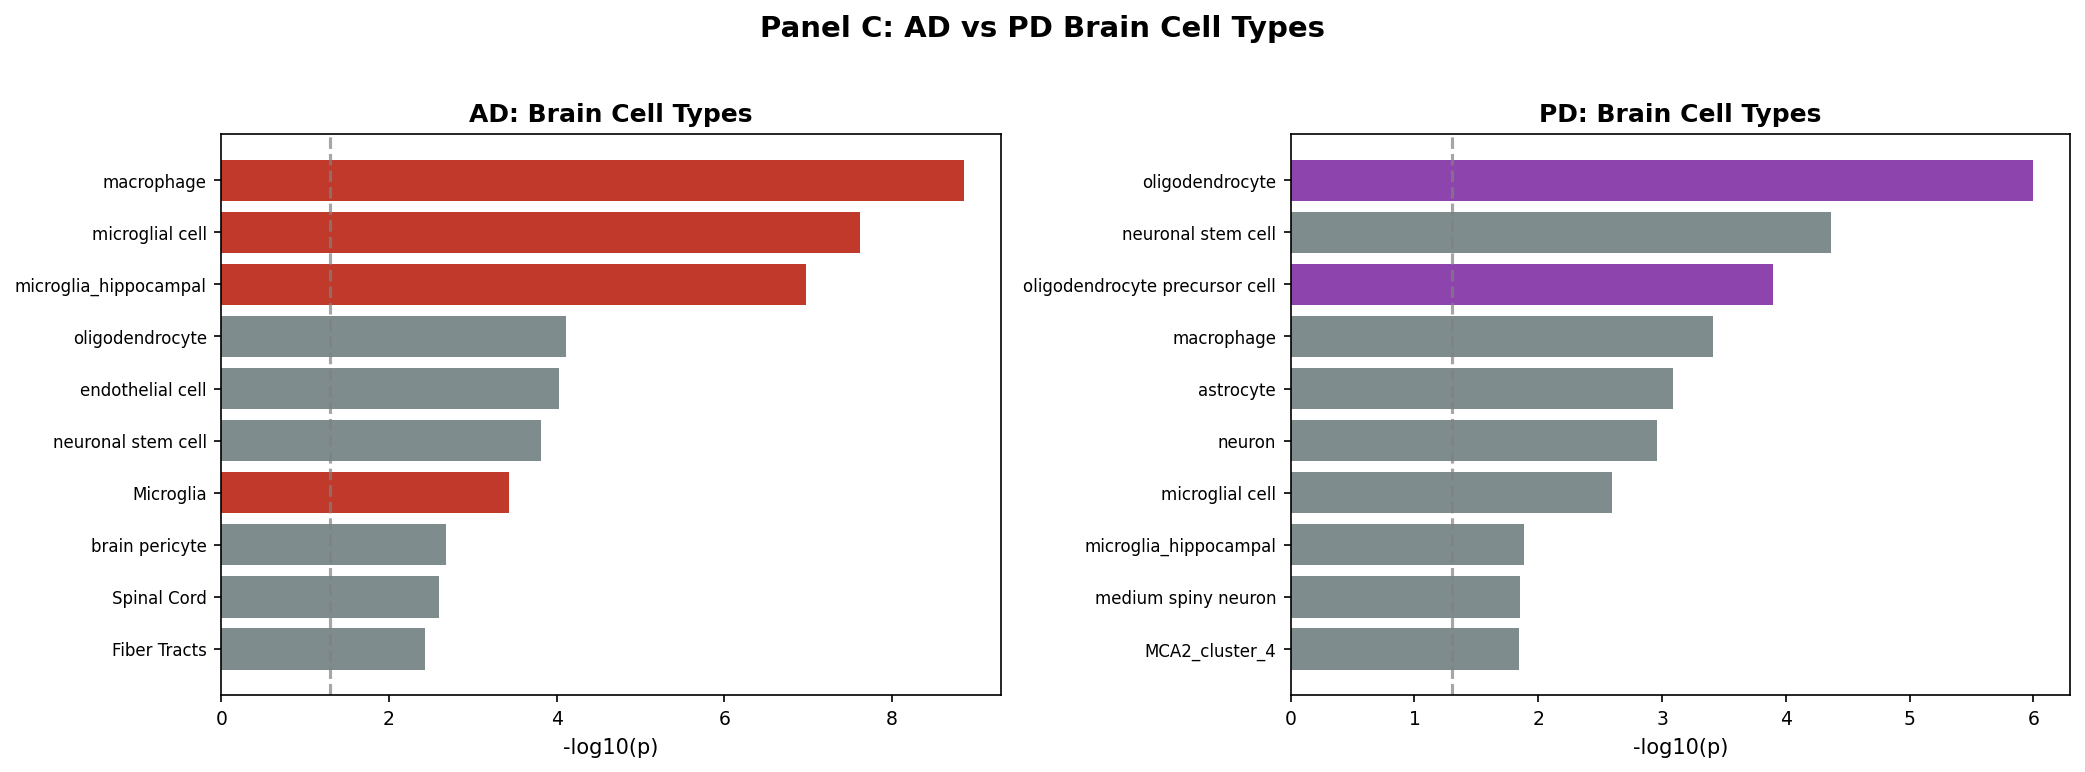

In [4]:
# Panel C: AD vs PD brain cell types

brain_data = all_data[all_data['organ'] == 'Brain'].copy()

# Get best p per annotation per trait across all brain samples
brain_best = brain_data.groupby(['trait', 'annotation']).agg(
    p_cauchy=('p_cauchy', 'min')
).reset_index()
brain_best['logp'] = -np.log10(brain_best['p_cauchy'].clip(lower=1e-300))

# AD top cell types
ad_brain = brain_best[brain_best['trait'] == 'AD'].sort_values('logp', ascending=False).head(10)
pd_brain = brain_best[brain_best['trait'] == 'PD'].sort_values('logp', ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# AD
colors_ad = ['#c0392b' if is_myeloid(a) else '#7f8c8d' for a in ad_brain['annotation']]
ax1.barh(range(len(ad_brain)), ad_brain['logp'].values, color=colors_ad)
ax1.set_yticks(range(len(ad_brain)))
ax1.set_yticklabels(ad_brain['annotation'].values, fontsize=8)
ax1.invert_yaxis()
ax1.set_xlabel('-log10(p)')
ax1.set_title('AD: Brain Cell Types', fontsize=12, fontweight='bold')
ax1.axvline(x=-np.log10(0.05), color='grey', linestyle='--', alpha=0.7)

# PD
def is_oligo(a):
    return 'oligo' in str(a).lower()
colors_pd = ['#8e44ad' if is_oligo(a) else '#7f8c8d' for a in pd_brain['annotation']]
ax2.barh(range(len(pd_brain)), pd_brain['logp'].values, color=colors_pd)
ax2.set_yticks(range(len(pd_brain)))
ax2.set_yticklabels(pd_brain['annotation'].values, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel('-log10(p)')
ax2.set_title('PD: Brain Cell Types', fontsize=12, fontweight='bold')
ax2.axvline(x=-np.log10(0.05), color='grey', linestyle='--', alpha=0.7)

plt.suptitle('Panel C: AD vs PD Brain Cell Types', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

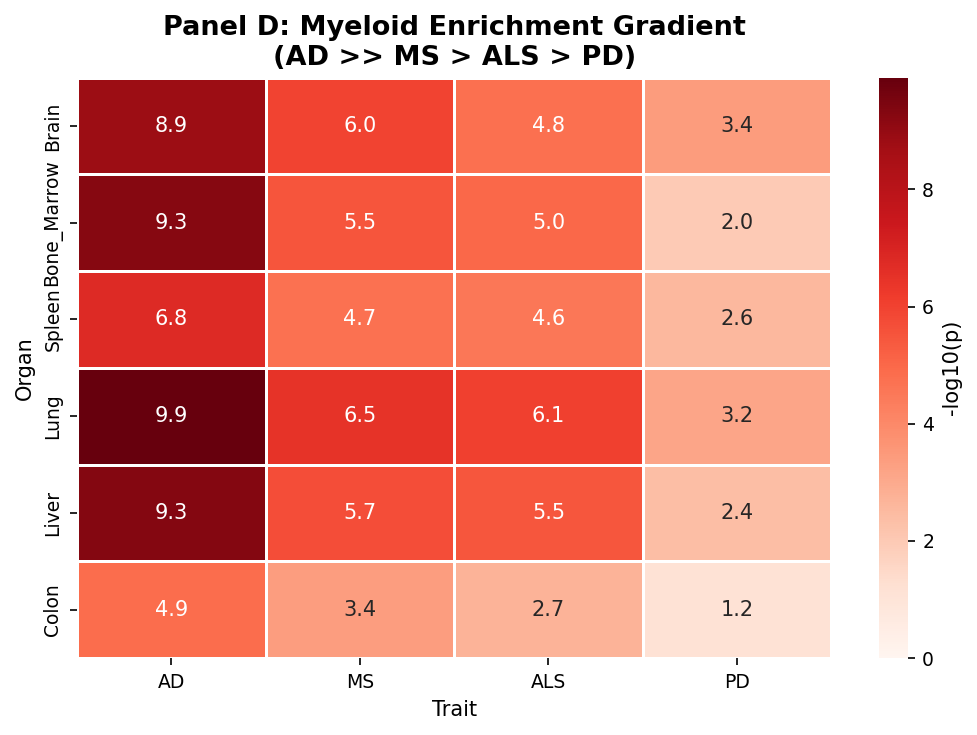

In [5]:
# Panel D: Myeloid enrichment gradient across neurodegen traits

myeloid_data = all_data[all_data['is_myeloid']].copy()
myeloid_organs = ['Brain', 'Bone_Marrow', 'Spleen', 'Lung', 'Liver', 'Colon']
nd_traits = ['AD', 'MS', 'ALS', 'PD']

# Best myeloid p per organ per trait
myeloid_best = myeloid_data[myeloid_data['organ'].isin(myeloid_organs)].groupby(
    ['trait', 'organ']
).agg(p_cauchy=('p_cauchy', 'min')).reset_index()
myeloid_best['logp'] = -np.log10(myeloid_best['p_cauchy'].clip(lower=1e-300))

myeloid_heat = myeloid_best[myeloid_best['trait'].isin(nd_traits)].pivot_table(
    index='organ', columns='trait', values='logp', aggfunc='max'
)
myeloid_heat = myeloid_heat.reindex(index=myeloid_organs, columns=nd_traits).fillna(0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    myeloid_heat, annot=True, fmt='.1f', cmap='Reds',
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label': '-log10(p)'}, vmin=0
)
ax.set_title('Panel D: Myeloid Enrichment Gradient\n(AD >> MS > ALS > PD)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Organ')
ax.set_xlabel('Trait')
plt.tight_layout()
plt.show()

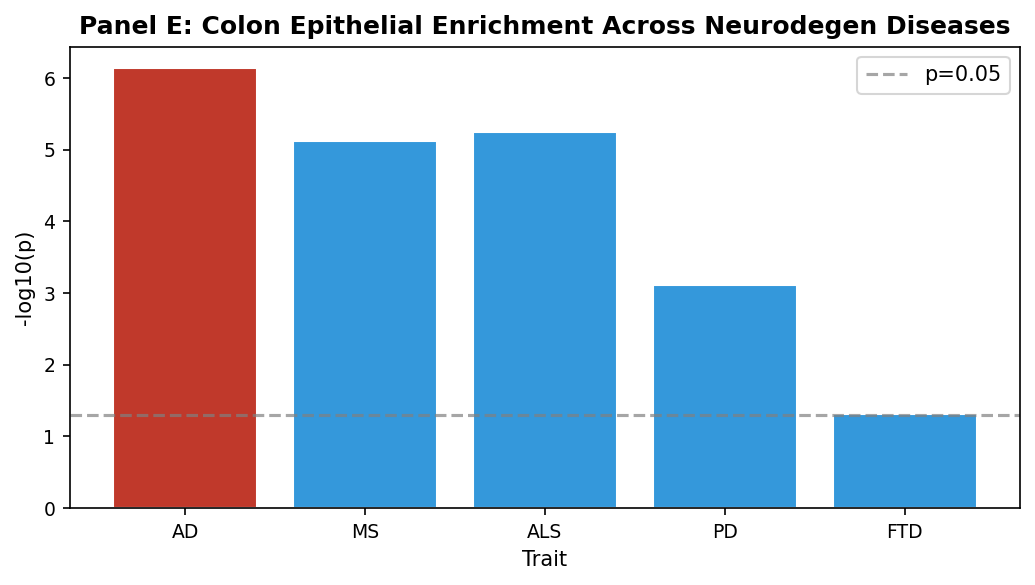

In [6]:
# Panel E: Colon epithelial across 5 neurodegen diseases

epithelial_kw = ['epithelial', 'epithelium', 'enterocyte', 'goblet', 'colonocyte',
                 'intestinal crypt stem', 'tuft', 'enteroendocrine', 'brush cell',
                 'secretory', 'paneth']

def is_epithelial(annot):
    a = str(annot).lower()
    return any(kw in a for kw in epithelial_kw)

colon_data = all_data[all_data['organ'] == 'Colon'].copy()
colon_epi = colon_data[colon_data['annotation'].apply(is_epithelial)]

# Best epithelial p per trait in colon
colon_epi_best = colon_epi.groupby('trait').agg(
    p_cauchy=('p_cauchy', 'min')
).reset_index()
colon_epi_best['logp'] = -np.log10(colon_epi_best['p_cauchy'].clip(lower=1e-300))

# Filter to neurodegen and order
colon_epi_nd = colon_epi_best[colon_epi_best['trait'].isin(NEURODEGEN)].copy()
colon_epi_nd['trait'] = pd.Categorical(colon_epi_nd['trait'], categories=NEURODEGEN, ordered=True)
colon_epi_nd = colon_epi_nd.sort_values('trait')

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#c0392b' if t == 'AD' else '#3498db' for t in colon_epi_nd['trait']]
ax.bar(colon_epi_nd['trait'].astype(str), colon_epi_nd['logp'], color=colors, edgecolor='white')
ax.axhline(y=-np.log10(0.05), color='grey', linestyle='--', alpha=0.7, label='p=0.05')
ax.set_ylabel('-log10(p)')
ax.set_xlabel('Trait')
ax.set_title('Panel E: Colon Epithelial Enrichment Across Neurodegen Diseases',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

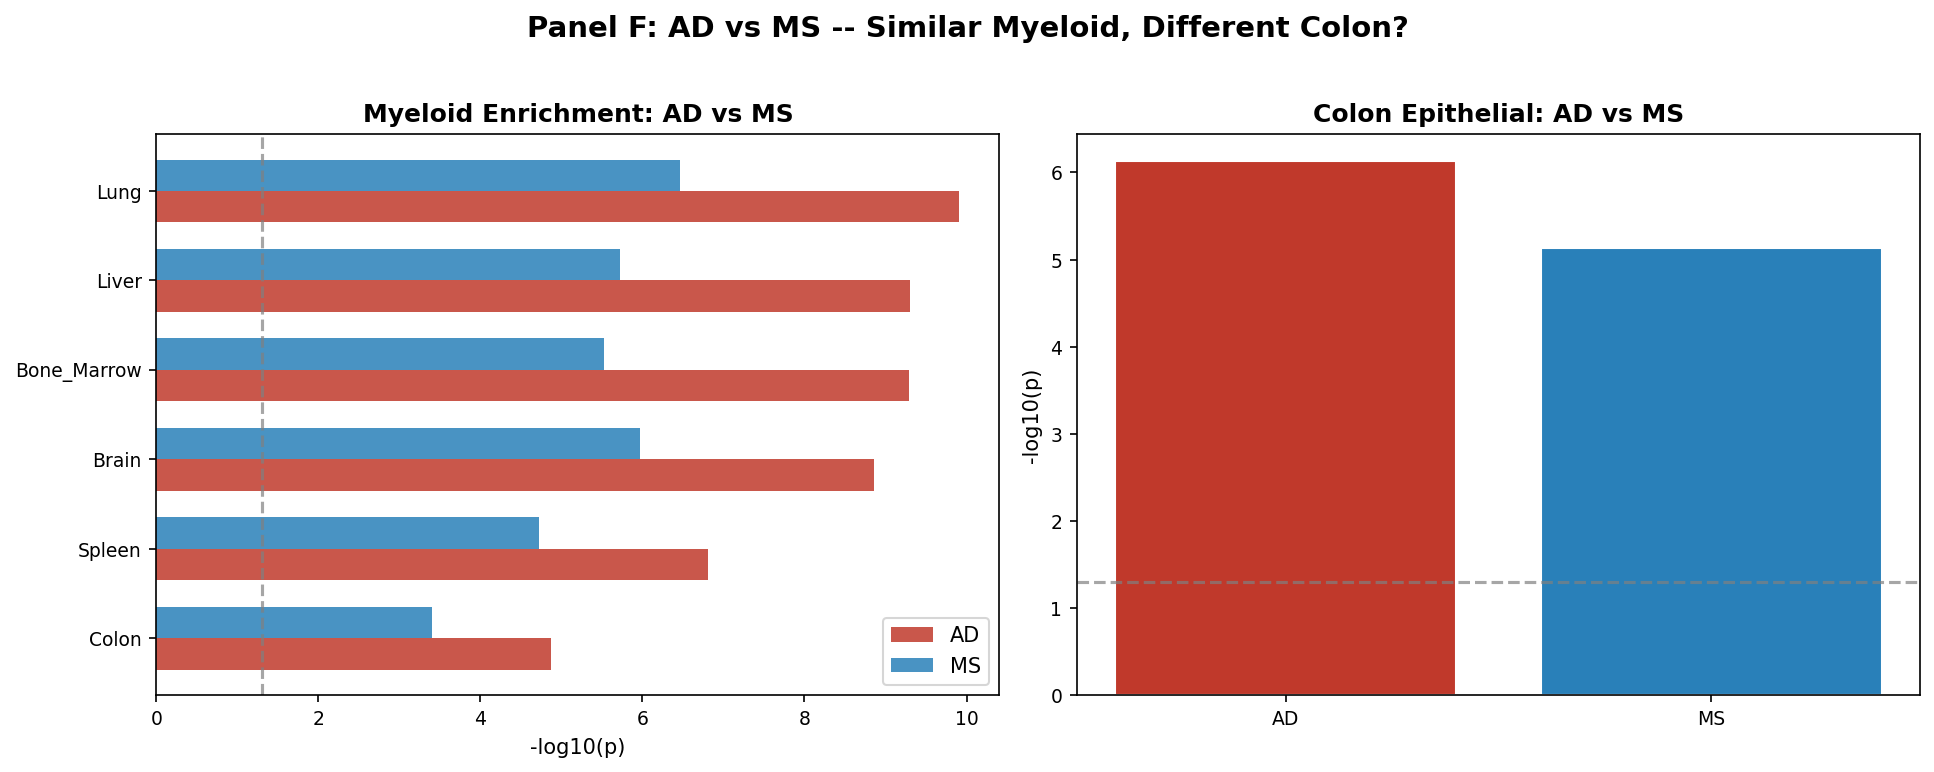

In [7]:
# Panel F: AD vs MS - similar myeloid but different colon pattern

# Myeloid comparison across organs
ad_ms_myeloid = myeloid_best[myeloid_best['trait'].isin(['AD', 'MS'])].copy()
ad_ms_myeloid_pivot = ad_ms_myeloid.pivot_table(
    index='organ', columns='trait', values='logp', aggfunc='max'
).fillna(0)

# Colon epithelial comparison
colon_epi_adms = colon_epi_best[colon_epi_best['trait'].isin(['AD', 'MS'])].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Myeloid comparison
if len(ad_ms_myeloid_pivot) > 0:
    if 'AD' in ad_ms_myeloid_pivot.columns:
        organs_sorted = ad_ms_myeloid_pivot.sort_values('AD', ascending=True).index
    else:
        organs_sorted = ad_ms_myeloid_pivot.index
    x = np.arange(len(organs_sorted))
    w = 0.35
    ad_vals = ad_ms_myeloid_pivot.loc[organs_sorted, 'AD'].values if 'AD' in ad_ms_myeloid_pivot.columns else np.zeros(len(organs_sorted))
    ms_vals = ad_ms_myeloid_pivot.loc[organs_sorted, 'MS'].values if 'MS' in ad_ms_myeloid_pivot.columns else np.zeros(len(organs_sorted))
    ax1.barh(x - w/2, ad_vals, w, label='AD', color='#c0392b', alpha=0.85)
    ax1.barh(x + w/2, ms_vals, w, label='MS', color='#2980b9', alpha=0.85)
    ax1.set_yticks(x)
    ax1.set_yticklabels(organs_sorted)
    ax1.set_xlabel('-log10(p)')
    ax1.set_title('Myeloid Enrichment: AD vs MS', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.axvline(x=-np.log10(0.05), color='grey', linestyle='--', alpha=0.7)

# Right: Colon epithelial comparison
ad_colon_v = colon_epi_adms[colon_epi_adms['trait']=='AD']['logp'].values
ms_colon_v = colon_epi_adms[colon_epi_adms['trait']=='MS']['logp'].values
ad_c = ad_colon_v[0] if len(ad_colon_v) > 0 else 0
ms_c = ms_colon_v[0] if len(ms_colon_v) > 0 else 0
ax2.bar(['AD', 'MS'], [ad_c, ms_c], color=['#c0392b', '#2980b9'], edgecolor='white')
ax2.axhline(y=-np.log10(0.05), color='grey', linestyle='--', alpha=0.7)
ax2.set_ylabel('-log10(p)')
ax2.set_title('Colon Epithelial: AD vs MS', fontsize=12, fontweight='bold')

plt.suptitle('Panel F: AD vs MS -- Similar Myeloid, Different Colon?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

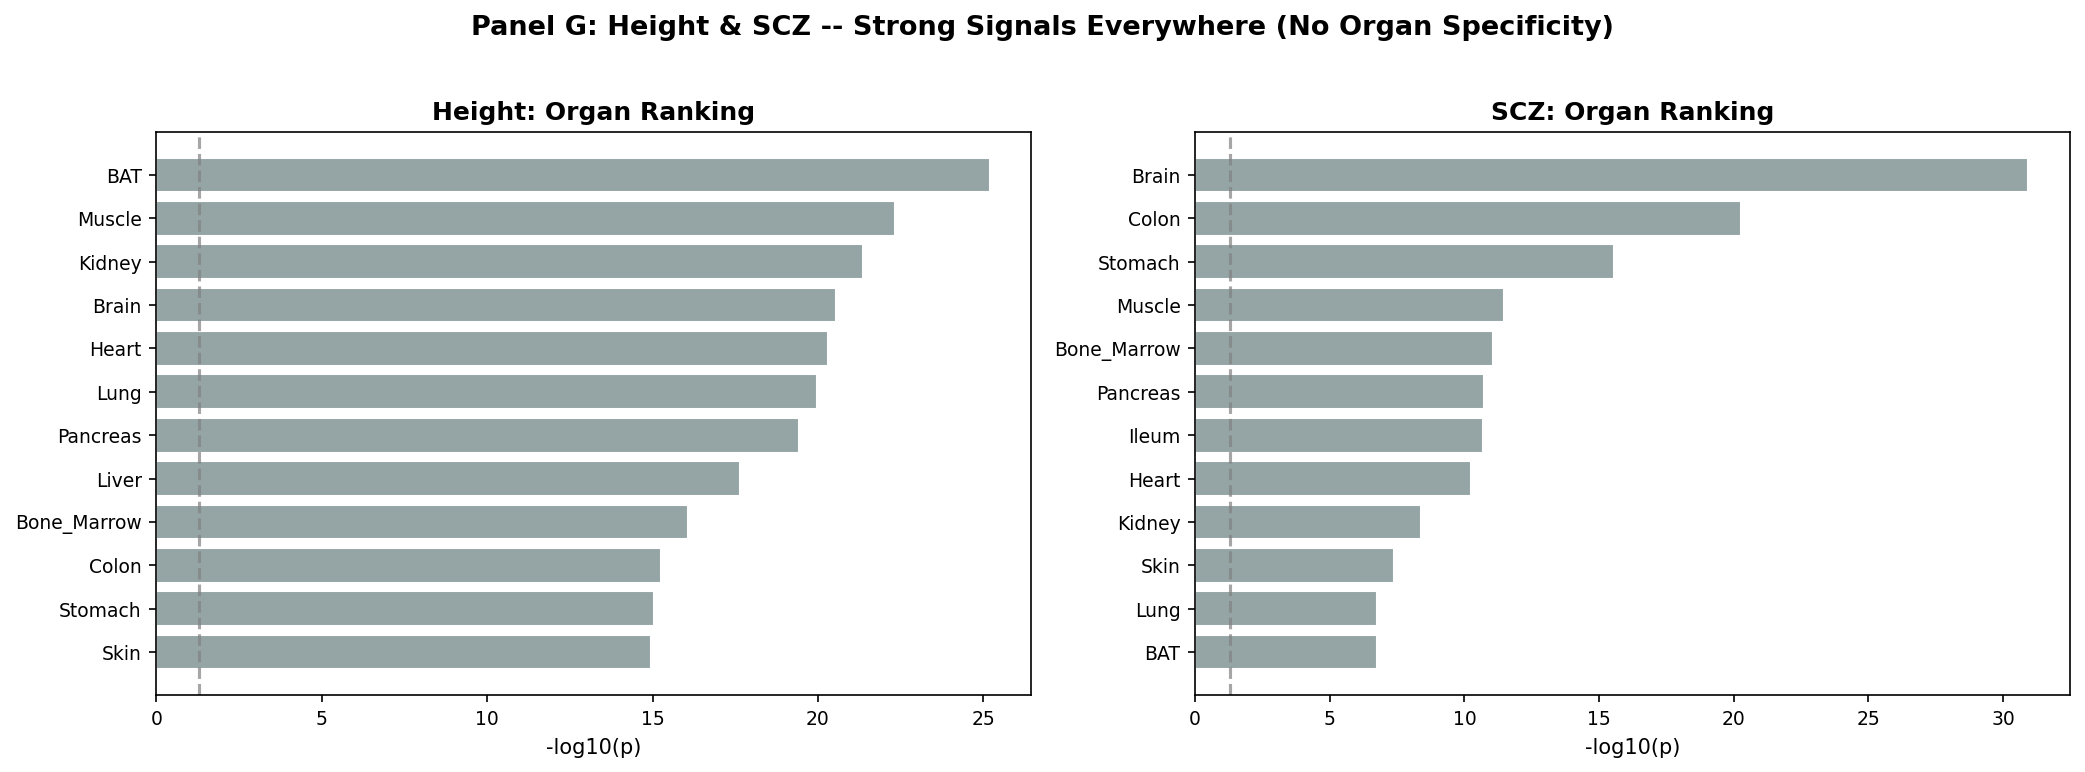

In [8]:
# Panel G: Height/SCZ as negative controls (no organ specificity)

control_traits = ['Height', 'SCZ']
control_data = organ_best[organ_best['trait'].isin(control_traits)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for i, trait in enumerate(control_traits):
    tdf = control_data[control_data['trait'] == trait].sort_values('logp', ascending=False).head(12)
    ax = axes[i]
    ax.barh(range(len(tdf)), tdf['logp'].values, color='#95a5a6', edgecolor='white')
    ax.set_yticks(range(len(tdf)))
    ax.set_yticklabels(tdf['organ'].values)
    ax.invert_yaxis()
    ax.set_xlabel('-log10(p)')
    ax.set_title(f'{trait}: Organ Ranking', fontsize=12, fontweight='bold')
    ax.axvline(x=-np.log10(0.05), color='grey', linestyle='--', alpha=0.7)

plt.suptitle('Panel G: Height & SCZ -- Strong Signals Everywhere (No Organ Specificity)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Saved: figures/paper1/Fig5_multi_trait.png and .pdf


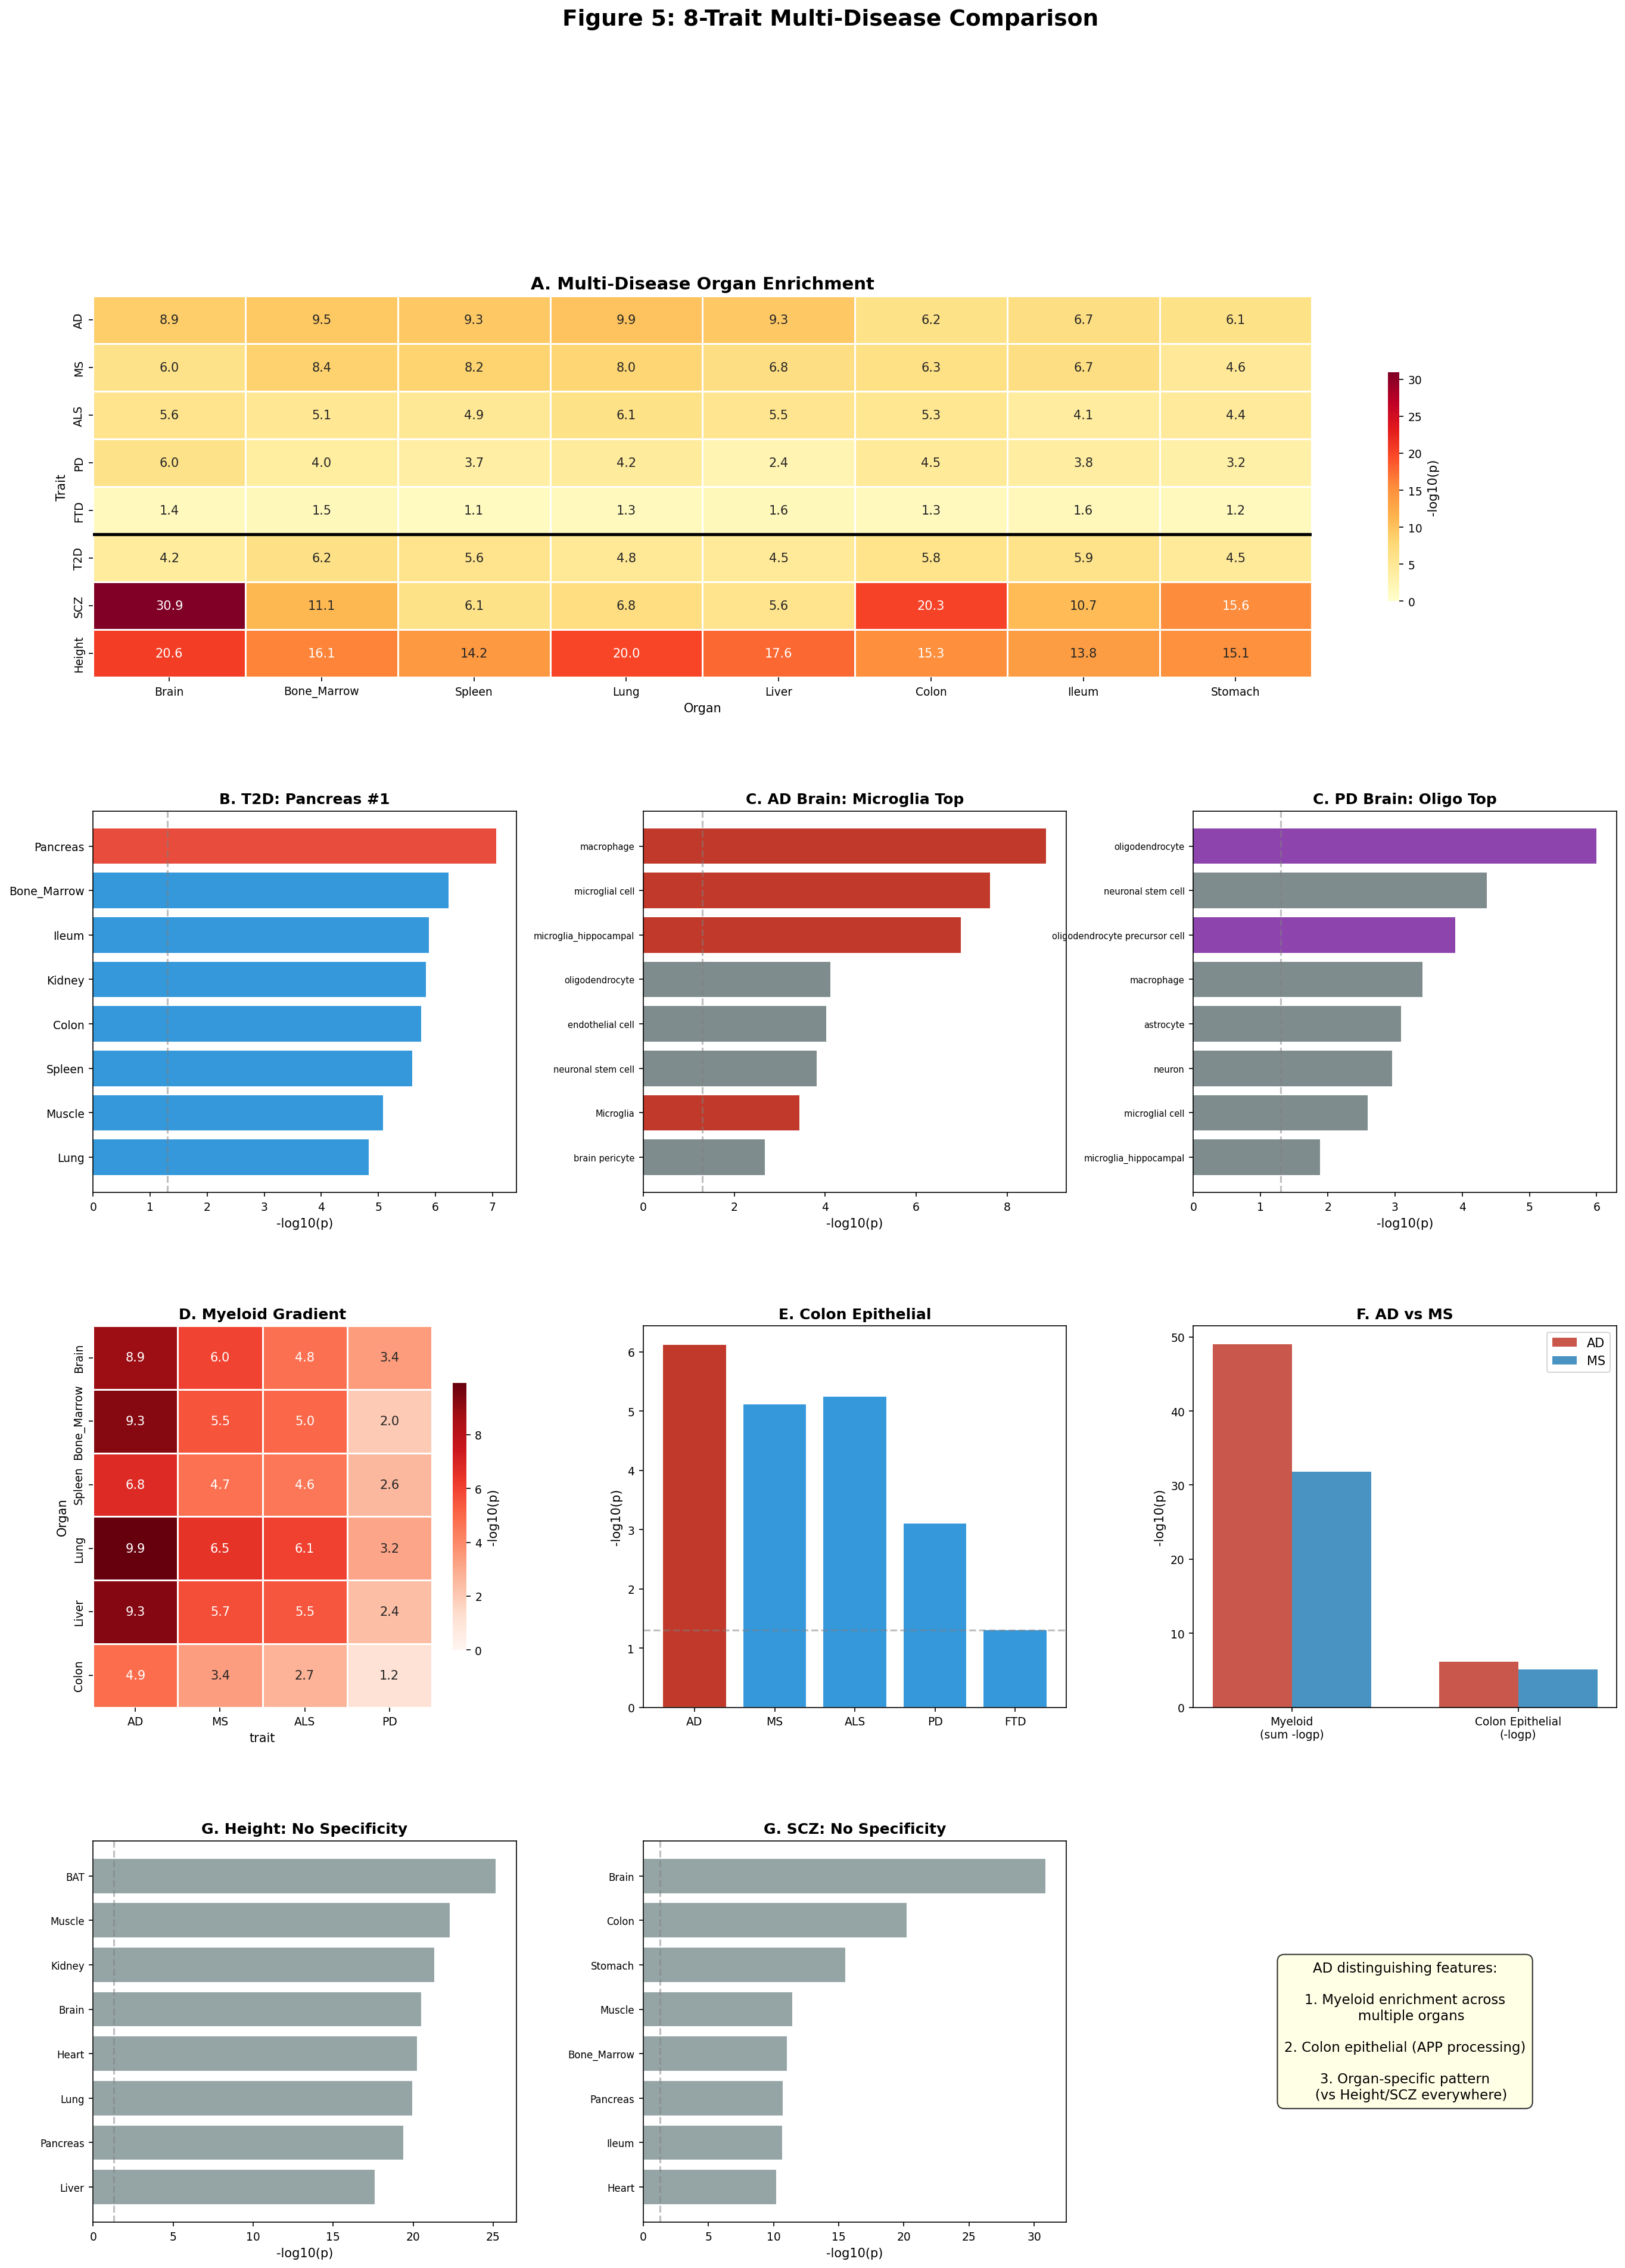

In [9]:
# Composite Figure 5

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(22, 28))
gs = GridSpec(4, 3, figure=fig, hspace=0.35, wspace=0.3,
              height_ratios=[1, 1, 1, 1])

# Panel A: 8-trait x 8-organ heatmap (top, spans full width)
ax_a = fig.add_subplot(gs[0, :])
sns.heatmap(
    heat_df.T, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white', ax=ax_a,
    cbar_kws={'label': '-log10(p)', 'shrink': 0.6}, vmin=0
)
ax_a.axhline(y=5, color='black', linewidth=2.5)
ax_a.set_title('A. Multi-Disease Organ Enrichment', fontsize=14, fontweight='bold')
ax_a.set_xlabel('Organ')
ax_a.set_ylabel('Trait')

# Panel B: T2D validation
ax_b = fig.add_subplot(gs[1, 0])
t2d_plot = organ_best[organ_best['trait'] == 'T2D'].sort_values('logp', ascending=False).head(8)
colors_b = ['#e74c3c' if o == 'Pancreas' else '#3498db' for o in t2d_plot['organ']]
ax_b.barh(range(len(t2d_plot)), t2d_plot['logp'].values, color=colors_b)
ax_b.set_yticks(range(len(t2d_plot)))
ax_b.set_yticklabels(t2d_plot['organ'].values)
ax_b.invert_yaxis()
ax_b.set_xlabel('-log10(p)')
ax_b.set_title('B. T2D: Pancreas #1', fontsize=12, fontweight='bold')
ax_b.axvline(x=-np.log10(0.05), color='grey', linestyle='--', alpha=0.5)

# Panel C: AD brain cell types
ax_c1 = fig.add_subplot(gs[1, 1])
ad_brain_top = brain_best[brain_best['trait'] == 'AD'].sort_values('logp', ascending=False).head(8)
colors_c1 = ['#c0392b' if is_myeloid(a) else '#7f8c8d' for a in ad_brain_top['annotation']]
ax_c1.barh(range(len(ad_brain_top)), ad_brain_top['logp'].values, color=colors_c1)
ax_c1.set_yticks(range(len(ad_brain_top)))
ax_c1.set_yticklabels(ad_brain_top['annotation'].values, fontsize=7)
ax_c1.invert_yaxis()
ax_c1.set_xlabel('-log10(p)')
ax_c1.set_title('C. AD Brain: Microglia Top', fontsize=12, fontweight='bold')
ax_c1.axvline(x=-np.log10(0.05), color='grey', linestyle='--', alpha=0.5)

# Panel C2: PD brain cell types
ax_c2 = fig.add_subplot(gs[1, 2])
pd_brain_top = brain_best[brain_best['trait'] == 'PD'].sort_values('logp', ascending=False).head(8)
colors_c2 = ['#8e44ad' if is_oligo(a) else '#7f8c8d' for a in pd_brain_top['annotation']]
ax_c2.barh(range(len(pd_brain_top)), pd_brain_top['logp'].values, color=colors_c2)
ax_c2.set_yticks(range(len(pd_brain_top)))
ax_c2.set_yticklabels(pd_brain_top['annotation'].values, fontsize=7)
ax_c2.invert_yaxis()
ax_c2.set_xlabel('-log10(p)')
ax_c2.set_title('C. PD Brain: Oligo Top', fontsize=12, fontweight='bold')
ax_c2.axvline(x=-np.log10(0.05), color='grey', linestyle='--', alpha=0.5)

# Panel D: Myeloid gradient heatmap
ax_d = fig.add_subplot(gs[2, 0])
sns.heatmap(
    myeloid_heat, annot=True, fmt='.1f', cmap='Reds',
    linewidths=0.5, linecolor='white', ax=ax_d,
    cbar_kws={'label': '-log10(p)', 'shrink': 0.7}, vmin=0
)
ax_d.set_title('D. Myeloid Gradient', fontsize=12, fontweight='bold')
ax_d.set_ylabel('Organ')

# Panel E: Colon epithelial across neurodegen
ax_e = fig.add_subplot(gs[2, 1])
if len(colon_epi_nd) > 0:
    colors_e = ['#c0392b' if t == 'AD' else '#3498db' for t in colon_epi_nd['trait']]
    ax_e.bar(colon_epi_nd['trait'].astype(str), colon_epi_nd['logp'], color=colors_e, edgecolor='white')
    ax_e.axhline(y=-np.log10(0.05), color='grey', linestyle='--', alpha=0.5)
ax_e.set_ylabel('-log10(p)')
ax_e.set_title('E. Colon Epithelial', fontsize=12, fontweight='bold')

# Panel F: AD vs MS comparison
ax_f = fig.add_subplot(gs[2, 2])
ad_myeloid_sum = myeloid_heat['AD'].sum() if 'AD' in myeloid_heat.columns else 0
ms_myeloid_sum = myeloid_heat['MS'].sum() if 'MS' in myeloid_heat.columns else 0
ad_colon = colon_epi_best[colon_epi_best['trait']=='AD']['logp'].values
ms_colon = colon_epi_best[colon_epi_best['trait']=='MS']['logp'].values
ad_colon_v = ad_colon[0] if len(ad_colon) > 0 else 0
ms_colon_v = ms_colon[0] if len(ms_colon) > 0 else 0

x_pos = np.arange(2)
w = 0.35
ax_f.bar(x_pos - w/2, [ad_myeloid_sum, ad_colon_v], w, label='AD', color='#c0392b', alpha=0.85)
ax_f.bar(x_pos + w/2, [ms_myeloid_sum, ms_colon_v], w, label='MS', color='#2980b9', alpha=0.85)
ax_f.set_xticks(x_pos)
ax_f.set_xticklabels(['Myeloid\n(sum -logp)', 'Colon Epithelial\n(-logp)'])
ax_f.set_ylabel('-log10(p)')
ax_f.set_title('F. AD vs MS', fontsize=12, fontweight='bold')
ax_f.legend()

# Panel G: Height & SCZ negative controls
for gi, (trait, col_idx) in enumerate(zip(['Height', 'SCZ'], [0, 1])):
    ax_g = fig.add_subplot(gs[3, gi])
    tdf = organ_best[organ_best['trait'] == trait].sort_values('logp', ascending=False).head(8)
    ax_g.barh(range(len(tdf)), tdf['logp'].values, color='#95a5a6', edgecolor='white')
    ax_g.set_yticks(range(len(tdf)))
    ax_g.set_yticklabels(tdf['organ'].values, fontsize=8)
    ax_g.invert_yaxis()
    ax_g.set_xlabel('-log10(p)')
    ax_g.set_title(f'G. {trait}: No Specificity', fontsize=12, fontweight='bold')
    ax_g.axvline(x=-np.log10(0.05), color='grey', linestyle='--', alpha=0.5)

# Summary text box
ax_sum = fig.add_subplot(gs[3, 2])
ax_sum.axis('off')
ax_sum.text(0.5, 0.5, 'AD distinguishing features:\n\n'
            '1. Myeloid enrichment across\n   multiple organs\n\n'
            '2. Colon epithelial (APP processing)\n\n'
            '3. Organ-specific pattern\n   (vs Height/SCZ everywhere)',
            ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Figure 5: 8-Trait Multi-Disease Comparison',
             fontsize=18, fontweight='bold', y=0.995)

os.makedirs(os.path.join(BASE, 'figures/paper1'), exist_ok=True)
fig.savefig(os.path.join(BASE, 'figures/paper1/Fig5_multi_trait.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(BASE, 'figures/paper1/Fig5_multi_trait.pdf'), bbox_inches='tight')
print('Saved: figures/paper1/Fig5_multi_trait.png and .pdf')
plt.show()